<a href="https://colab.research.google.com/github/Himanshu530-collab/BlogSphere/blob/main/testing_working.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving test_image.zip to test_image.zip


In [2]:
import zipfile
import os

zip_path = "test_image.zip"   # Your zipped test_image folder
extract_dir = "test_image"    # Folder to extract into

# Make sure the extraction folder exists
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ Unzipped '{zip_path}' into '{extract_dir}'")


✅ Unzipped 'test_image.zip' into 'test_image'


In [3]:
from google.colab import files

uploaded = files.upload()  # This will prompt you to select files from your computer

# After uploading, you can check if the file is uploaded:
import os
print(os.listdir())


Saving dental_cnn_final.pth to dental_cnn_final.pth
['.config', 'dental_cnn_final.pth', 'test_image.zip', 'test_image', 'sample_data']


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


In [10]:
class DentalCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(DentalCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout_conv = nn.Dropout(0.25)
        self.dropout_fc = nn.Dropout(0.5)

        self.fc1 = nn.Linear(1024 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.conv3(x)))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.conv4(x)))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.conv5(x)))
        x = self.dropout_conv(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Make sure num_classes matches the original training
num_classes = 5
model = DentalCNN(num_classes=num_classes).to(device)

# Load trained weights
model.load_state_dict(torch.load('dental_cnn_final.pth', map_location=device))
model.eval()  # switch to inference mode


DentalCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_conv): Dropout(p=0.25, inplace=False)
  (dropout_fc): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=5, bias=True)
)

In [12]:
import os
from PIL import Image
import torch
from torchvision import transforms

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Load your model class and trained weights (already done earlier)
# Make sure your model is defined and loaded here:
# model = DentalCNN(num_classes=5).to(device)
# model.load_state_dict(torch.load('dental_cnn_final.pth', map_location=device))
# model.eval()

# Define the same transform used in training (without RandomHorizontalFlip for test)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Class names
class_names = ['gingivitis', 'hypodontia', 'mouth_ulcer', 'tartar', 'tooth_discoloration']

# Folder containing test images
test_dir = 'test_image/test_image/Teeth Images'  # Adjust if needed
valid_exts = ('.jpg', '.jpeg', '.png')

# Inference loop
model.eval()
for img_name in os.listdir(test_dir):
    if not img_name.lower().endswith(valid_exts):
        continue

    img_path = os.path.join(test_dir, img_name)

    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f"❌ Error loading image {img_path}: {e}")
        continue

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, preds = torch.max(outputs, 1)

    print(f"🖼️ Image: {img_name} ➡️ Predicted class: {class_names[preds.item()]}")


Using device: cpu
🖼️ Image: (7).JPG ➡️ Predicted class: hypodontia
🖼️ Image: (1).JPG ➡️ Predicted class: hypodontia
🖼️ Image: (9).JPG ➡️ Predicted class: hypodontia
🖼️ Image: 12.jpg ➡️ Predicted class: mouth_ulcer
🖼️ Image: 38.jpg ➡️ Predicted class: tooth_discoloration
🖼️ Image: 20.jpg ➡️ Predicted class: mouth_ulcer
🖼️ Image: 16.jpg ➡️ Predicted class: hypodontia
🖼️ Image: (41).jpg ➡️ Predicted class: gingivitis
🖼️ Image: 18.jpg ➡️ Predicted class: mouth_ulcer
🖼️ Image: 17.jpg ➡️ Predicted class: mouth_ulcer
🖼️ Image: (24).jpg ➡️ Predicted class: tartar
🖼️ Image: (6).JPG ➡️ Predicted class: hypodontia
🖼️ Image: 13.jpg ➡️ Predicted class: mouth_ulcer
🖼️ Image: (44).jpg ➡️ Predicted class: gingivitis
🖼️ Image: 40.jpg ➡️ Predicted class: tooth_discoloration
🖼️ Image: (8).JPG ➡️ Predicted class: hypodontia
🖼️ Image: (26).jpg ➡️ Predicted class: tartar
🖼️ Image: (50).jpg ➡️ Predicted class: gingivitis
🖼️ Image: (47).jpg ➡️ Predicted class: gingivitis
🖼️ Image: (43).jpg ➡️ Predicted class:

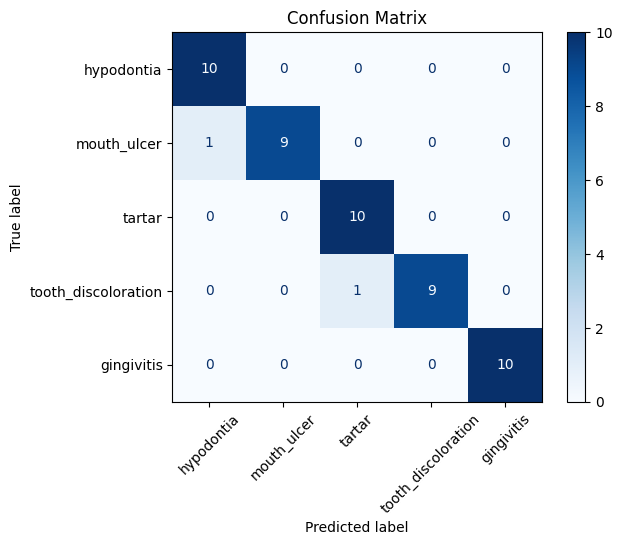

In [13]:
import re
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_true_label(img_num):
    if 1 <= img_num <= 10:
        return 'hypodontia'
    elif 11 <= img_num <= 20:
        return 'mouth_ulcer'
    elif 21 <= img_num <= 30:
        return 'tartar'
    elif 31 <= img_num <= 40:
        return 'tooth_discoloration'
    elif 41 <= img_num <= 50:
        return 'gingivitis'
    else:
        return None

predicted_lines = [
    "Image: (7).JPG --> Predicted class: hypodontia",
    "Image: (1).JPG --> Predicted class: hypodontia",
    "Image: (9).JPG --> Predicted class: hypodontia",
    "Image: 12.jpg --> Predicted class: mouth_ulcer",
    "Image: 38.jpg --> Predicted class: tooth_discoloration",
    "Image: 20.jpg --> Predicted class: mouth_ulcer",
    "Image: 16.jpg --> Predicted class: hypodontia",
    "Image: (41).jpg --> Predicted class: gingivitis",
    "Image: 18.jpg --> Predicted class: mouth_ulcer",
    "Image: 17.jpg --> Predicted class: mouth_ulcer",
    "Image: (24).jpg --> Predicted class: tartar",
    "Image: (6).JPG --> Predicted class: hypodontia",
    "Image: 13.jpg --> Predicted class: mouth_ulcer",
    "Image: (44).jpg --> Predicted class: gingivitis",
    "Image: 40.jpg --> Predicted class: tooth_discoloration",
    "Image: (8).JPG --> Predicted class: hypodontia",
    "Image: (26).jpg --> Predicted class: tartar",
    "Image: (50).jpg --> Predicted class: gingivitis",
    "Image: (47).jpg --> Predicted class: gingivitis",
    "Image: (43).jpg --> Predicted class: gingivitis",
    "Image: (2).JPG --> Predicted class: hypodontia",
    "Image: (49).jpg --> Predicted class: gingivitis",
    "Image: 32.jpg --> Predicted class: tooth_discoloration",
    "Image: (23).jpg --> Predicted class: tartar",
    "Image: (10).JPG --> Predicted class: hypodontia",
    "Image: 36.jpg --> Predicted class: tooth_discoloration",
    "Image: 34.jpg --> Predicted class: tooth_discoloration",
    "Image: (21).jpg --> Predicted class: tartar",
    "Image: (30).jpg --> Predicted class: tartar",
    "Image: 19.jpg --> Predicted class: mouth_ulcer",
    "Image: 31.jpg --> Predicted class: tooth_discoloration",
    "Image: 14.jpg --> Predicted class: mouth_ulcer",
    "Image: (48).jpg --> Predicted class: gingivitis",
    "Image: 39.jpg --> Predicted class: tooth_discoloration",
    "Image: 11.jpg --> Predicted class: mouth_ulcer",
    "Image: 15.jpg --> Predicted class: mouth_ulcer",
    "Image: 35.jpg --> Predicted class: tooth_discoloration",
    "Image: (25).jpg --> Predicted class: tartar",
    "Image: (22).jpg --> Predicted class: tartar",
    "Image: 33.jpg --> Predicted class: tooth_discoloration",
    "Image: (3).JPG --> Predicted class: hypodontia",
    "Image: (28).jpg --> Predicted class: tartar",
    "Image: (46).jpg --> Predicted class: gingivitis",
    "Image: (27).jpg --> Predicted class: tartar",
    "Image: (29).jpg --> Predicted class: tartar",
    "Image: (42).jpg --> Predicted class: gingivitis",
    "Image: (45).jpg --> Predicted class: gingivitis",
    "Image: (4).JPG --> Predicted class: hypodontia",
    "Image: 37.jpg --> Predicted class: tartar",
    "Image: (5).JPG --> Predicted class: hypodontia"
]

true_labels = []
pred_labels = []

# Regex updated to accept optional parentheses and class names with underscores
pattern = re.compile(r'Image: \(?(\d+)\)?\.\w+ --> Predicted class: ([a-z_]+)')

for line in predicted_lines:
    match = pattern.search(line)
    if match:
        img_num = int(match.group(1))
        pred_class = match.group(2).lower()
        true_class = get_true_label(img_num)
        if true_class:
            true_labels.append(true_class)
            pred_labels.append(pred_class)

# Define class order to keep matrix consistent
classes = ['hypodontia', 'mouth_ulcer', 'tartar', 'tooth_discoloration', 'gingivitis']

cm = confusion_matrix(true_labels, pred_labels, labels=classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [14]:
import re
from collections import defaultdict

# Define image ranges for each class
def get_true_label(img_num):
    if 1 <= img_num <= 10:
        return 'hypodontia'
    elif 11 <= img_num <= 20:
        return 'mouth_ulcer'
    elif 21 <= img_num <= 30:
        return 'tartar'
    elif 31 <= img_num <= 40:
        return 'tooth_discoloration'
    elif 41 <= img_num <= 50:
        return 'gingivitis'
    else:
        return None

# Updated predicted results with your given lines
predicted_lines = [
    "Image: (7).JPG --> Predicted class: hypodontia",
    "Image: (1).JPG --> Predicted class: hypodontia",
    "Image: (9).JPG --> Predicted class: hypodontia",
    "Image: 12.jpg --> Predicted class: mouth_ulcer",
    "Image: 38.jpg --> Predicted class: tooth_discoloration",
    "Image: 20.jpg --> Predicted class: mouth_ulcer",
    "Image: 16.jpg --> Predicted class: hypodontia",
    "Image: (41).jpg --> Predicted class: gingivitis",
    "Image: 18.jpg --> Predicted class: mouth_ulcer",
    "Image: 17.jpg --> Predicted class: mouth_ulcer",
    "Image: (24).jpg --> Predicted class: tartar",
    "Image: (6).JPG --> Predicted class: hypodontia",
    "Image: 13.jpg --> Predicted class: mouth_ulcer",
    "Image: (44).jpg --> Predicted class: gingivitis",
    "Image: 40.jpg --> Predicted class: tooth_discoloration",
    "Image: (8).JPG --> Predicted class: hypodontia",
    "Image: (26).jpg --> Predicted class: tartar",
    "Image: (50).jpg --> Predicted class: gingivitis",
    "Image: (47).jpg --> Predicted class: gingivitis",
    "Image: (43).jpg --> Predicted class: gingivitis",
    "Image: (2).JPG --> Predicted class: hypodontia",
    "Image: (49).jpg --> Predicted class: gingivitis",
    "Image: 32.jpg --> Predicted class: tooth_discoloration",
    "Image: (23).jpg --> Predicted class: tartar",
    "Image: (10).JPG --> Predicted class: hypodontia",
    "Image: 36.jpg --> Predicted class: tooth_discoloration",
    "Image: 34.jpg --> Predicted class: tooth_discoloration",
    "Image: (21).jpg --> Predicted class: tartar",
    "Image: (30).jpg --> Predicted class: tartar",
    "Image: 19.jpg --> Predicted class: mouth_ulcer",
    "Image: 31.jpg --> Predicted class: tooth_discoloration",
    "Image: 14.jpg --> Predicted class: mouth_ulcer",
    "Image: (48).jpg --> Predicted class: gingivitis",
    "Image: 39.jpg --> Predicted class: tooth_discoloration",
    "Image: 11.jpg --> Predicted class: mouth_ulcer",
    "Image: 15.jpg --> Predicted class: mouth_ulcer",
    "Image: 35.jpg --> Predicted class: tooth_discoloration",
    "Image: (25).jpg --> Predicted class: tartar",
    "Image: (22).jpg --> Predicted class: tartar",
    "Image: 33.jpg --> Predicted class: tooth_discoloration",
    "Image: (3).JPG --> Predicted class: hypodontia",
    "Image: (28).jpg --> Predicted class: tartar",
    "Image: (46).jpg --> Predicted class: gingivitis",
    "Image: (27).jpg --> Predicted class: tartar",
    "Image: (29).jpg --> Predicted class: tartar",
    "Image: (42).jpg --> Predicted class: gingivitis",
    "Image: (45).jpg --> Predicted class: gingivitis",
    "Image: (4).JPG --> Predicted class: hypodontia",
    "Image: 37.jpg --> Predicted class: tartar",
    "Image: (5).JPG --> Predicted class: hypodontia"
]

correct = 0
total = 0
class_correct = defaultdict(int)
class_total = defaultdict(int)
misclassified_images = []

for line in predicted_lines:
    # Extract image number (inside parentheses or not)
    match = re.search(r'Image: \(?(\d+)\)?\.\w+ --> Predicted class: (\w+)', line)
    if match:
        img_num = int(match.group(1))
        pred_class = match.group(2).lower()

        true_class = get_true_label(img_num)

        if true_class:
            class_total[true_class] += 1
            total += 1

            if true_class == pred_class:
                correct += 1
                class_correct[true_class] += 1
            else:
                misclassified_images.append((img_num, true_class, pred_class))
        else:
            print(f"Image number {img_num} does not belong to any class range.")
    else:
        print(f"Could not parse line: {line}")

accuracy = correct / total if total > 0 else 0

print(f"Overall Accuracy: {accuracy*100:.2f}%")
print("\nClass-wise accuracy:")
for cls in class_total:
    acc = class_correct[cls] / class_total[cls] if class_total[cls] > 0 else 0
    print(f" - {cls}: {acc*100:.2f}%")

print("\nMisclassified Images:")
for img_num, true_cls, pred_cls in misclassified_images:
    print(f" Image {img_num}: True={true_cls}, Predicted={pred_cls}")


Overall Accuracy: 96.00%

Class-wise accuracy:
 - hypodontia: 100.00%
 - mouth_ulcer: 90.00%
 - tooth_discoloration: 90.00%
 - gingivitis: 100.00%
 - tartar: 100.00%

Misclassified Images:
 Image 16: True=mouth_ulcer, Predicted=hypodontia
 Image 37: True=tooth_discoloration, Predicted=tartar
